### Introduction
**Context**:
The database provides results and statistics for each team’s players for every match of the 2024/2025 NBA season, from the start right through to the final. The league comprises 30 teams divided into two conferences – the Eastern and Western Conferences – each with 15 teams, which will primarily compete against teams from their own conference before progressing to the play-offs, culminating in a final between the winners of each conference. The database therefore contains one row per player on a team for each match.

**Description of the columns**:
* Player: Name of the player.
* Tm: Abbreviation of the player's team.
* Opp: Abbreviation of the opposing team.
* Res: Result of the game for the player's team. (Win or Lose)
* MP: Minutes played, represented as a float (e.g., 23.5 = 23 minutes and 30 seconds).
* FG: Field goals made. (all types of goals)
* FGA: Field goal attempts.
* FG%: Field goal percentage.
* 3P: 3-point field goals made.
* 3PA: 3-point field goal attempts.
* 3P%: 3-point shooting percentage.
* FT: Free throws made. (worth 1 point each)
* FTA: Free throw attempts.
* FT%: Free throw percentage.
* ORB: Offensive rebounds. (giving the team another chance to score)
* DRB: Defensive rebounds. (preventing the opponent from scoring)
* TRB: Total rebounds.
* AST: Assists. Passes leading directly to a teammate’s score.
* STL: Steals. Times the player stole the ball from the opponent.
* BLK: Blocks. Times the player blocked an opponent’s shot.
* TOV: Turnovers. Times the player lost possession (e.g., bad pass, dribble error).
* PF: Personal fouls.
* PTS: Total points scored.
* GmSc: Game Score, a metric summarizing player performance for the game.
* Data: Date of the game in YYYY-MM-DD format.

**Objective**:
The aim of the project is to analyse NBA match statistics to see whether certain statistics are more important than others for winning, or which ones are worth looking at.

**How to Use This Notebook**
1. Prerequisites:
   - Install all required libraries by doing: pip install pandas python-dotenv openai matplotlib seaborn scikit-learn
   - You can download the file on my GitHub (named:nba_dailyleaders_full_24_25.csv) or by this link: https://www.kaggle.com/datasets/eduardopalmieri/nba-player-stats-season-2425
   -  place it in the same folder as this notebook.
2. Execution:
   - Run all cells in order.
   - If you want to use your own API key, replace `YOUR_API_KEY` in the first code cell.
3. Outputs:
   - You can find my cleaned data as in the GitHub `nba_teams_analysis.csv`

**Use of AI**


### Importing needed librairies

In [89]:
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.environ.get("GROQ_API_KEY")

from openai import OpenAI
client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)
MODEL = "llama-3.3-70b-versatile"

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

### Data uploaded

In [90]:
nba_df = pd.read_csv("nba_dailyleaders_full_24_25.csv", encoding="utf-8", sep=",")

### First analyse:

In [91]:
display(nba_df.head())
display(nba_df.shape)
display(nba_df.columns)
display(nba_df.describe())
display(nba_df.info())
display(nba_df.isnull().sum())

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,...,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,...,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,...,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,...,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,...,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22


(28265, 27)

Index(['Player', 'Tm', 'Unnamed: 3', 'Opp', 'Result', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', '+/-', 'GmSc', 'Date'],
      dtype='object')

,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc
count,28265.000000,28265.000000,26622.000000,28265.000000,28265.000000,22448.000000,28265.000000,28265.000000,15365.000000,28265.000000,28265.000000,28265.000000,28265.000000,28265.000000,28265.000000,28265.000000,28265.000000,28265.000000,28247.000000,28265.000000
mean,3.879887,8.319123,0.455368,1.258270,3.497400,0.334707,1.588785,2.038139,0.765673,1.038705,3.075889,4.114594,2.457775,0.765151,0.456536,1.259544,1.751176,10.606828,0.000177,8.650670
std,3.255030,6.068272,0.237988,1.525269,3.146204,0.283949,2.273846,2.734015,0.283624,1.379611,2.714491,3.471946,2.613973,0.989598,0.819571,1.415114,1.444915,8.844302,11.765434,7.842648
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-58.000000,-8.300000
25%,1.000000,4.000000,0.333000,0.000000,1.000000,0.000000,0.000000,0.000000,0.500000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4.000000,-7.000000,2.400000
50%,3.000000,7.000000,0.462000,1.000000,3.000000,0.333000,1.000000,1.000000,0.857000,1.000000,2.000000,3.000000,2.000000,0.000000,0.000000,1.000000,2.000000,9.000000,0.000000,7.200000
75%,6.000000,12.000000,0.588000,2.000000,5.000000,0.500000,2.000000,3.000000,1.000000,2.000000,4.000000,6.000000,4.000000,1.000000,1.000000,2.000000,3.000000,16.000000,7.000000,13.400000
max,22.000000,39.000000,1.000000,12.000000,20.000000,1.000000,21.000000,26.000000,1.000000,13.000000,23.000000,28.000000,22.000000,8.000000,10.000000,11.000000,6.000000,61.000000,51.000000,54.200000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28265 entries, 0 to 28264
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      28265 non-null  object 
 1   Tm          28265 non-null  object 
 2   Unnamed: 3  14057 non-null  object 
 3   Opp         28265 non-null  object 
 4   Result      28265 non-null  object 
 5   MP          28265 non-null  object 
 6   FG          28265 non-null  int64  
 7   FGA         28265 non-null  int64  
 8   FG%         26622 non-null  float64
 9   3P          28265 non-null  int64  
 10  3PA         28265 non-null  int64  
 11  3P%         22448 non-null  float64
 12  FT          28265 non-null  int64  
 13  FTA         28265 non-null  int64  
 14  FT%         15365 non-null  float64
 15  ORB         28265 non-null  int64  
 16  DRB         28265 non-null  int64  
 17  TRB         28265 non-null  int64  
 18  AST         28265 non-null  int64  
 19  STL         28265 non-nul

None

Player            0
Tm                0
Unnamed: 3    14208
Opp               0
Result            0
MP                0
FG                0
FGA               0
FG%            1643
3P                0
3PA               0
3P%            5817
FT                0
FTA               0
FT%           12900
ORB               0
DRB               0
TRB               0
AST               0
STL               0
BLK               0
TOV               0
PF                0
PTS               0
+/-              18
GmSc              0
Date              0
dtype: int64

### Creating a function to ask the AI for later

In [92]:
def ask_ai(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}])
    return response.choices[0].message.content


### Cleaning and transforming

In [93]:
#a) clean the first df
#Unnamed: 3 doesn't mean anything
nba_df= nba_df.drop(columns=["Unnamed: 3"])

#There are missing values in the three percentage columns because they represent the percentage of successful attempts, but there were no attempts, so I let them as missing value

df_by_teams = nba_df.sort_values(["Tm", "Date"])
display (df_by_teams.head())

,Player,Tm,Opp,Result,MP,FG,FGA,FG%,3P,3PA,...,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
44,Trae Young,ATL,BRK,W,36:40,7,16,0.438,2,6,...,5,12,1,1,3,1,30,12.0,29.4,2024-10-23
46,Onyeka Okongwu,ATL,BRK,W,28:29,11,12,0.917,0,0,...,8,1,0,3,2,1,28,4.0,28.4,2024-10-23
76,Dyson Daniels,ATL,BRK,W,34:32,6,12,0.500,2,4,...,5,2,5,1,1,4,15,7.0,15.0,2024-10-23
130,De'Andre Hunter,ATL,BRK,W,25:47,3,10,0.300,2,4,...,6,1,2,0,0,5,12,10.0,8.7,2024-10-23
141,Clint Capela,ATL,BRK,W,19:31,3,5,0.600,0,0,...,7,1,1,1,1,0,6,0.0,7.6,2024-10-23


In [94]:
#Goal: create a new df with means of statistics by teams to compare them

#1) calculate the number of matchs for each team to do the mean
player_by_matchs= nba_df.groupby(["Tm", "Date", "Opp"]).size()
match_by_team=player_by_matchs.groupby("Tm").size()
display("Number of match by teams :")
display(match_by_team)

#2) create the new df of means by teams 
columns_stats = [
    "FG", "FGA", "FG%", "3P", "3PA", "3P%", "FT", "FTA", "FT%",
    "ORB", "DRB", "TRB", "AST", "STL", "BLK", "TOV", "PF", "PTS", "+/-", "GmSc"
]
df_means_teams = nba_df.groupby("Tm")[columns_stats].sum().div(match_by_team, axis=0)

#3) add other intersting statistics 
df_means_teams["Match"] = match_by_team #add the number of match by teams
df_means_teams["Player"] = player_by_matchs.groupby("Tm").mean() #add the mean of players who played in a match
win_by_team = nba_df[nba_df["Result"] == "W"].groupby(["Tm","Date","Opp"]).size().groupby("Tm").size()
df_means_teams["Win%"] = (win_by_team / match_by_team) * 100 #add the % of win by team

#4) re calculate the % because mean calcul doesn't work the same for %
df_means_teams["FG%"]= df_means_teams["FG"]/df_means_teams["FGA"] *100
df_means_teams["3P%"]= df_means_teams["3P"]/df_means_teams["3PA"] *100
df_means_teams["FT%"]= df_means_teams["FT"]/df_means_teams["FTA"] *100

#5) round all the df to clarify it
df_means_teams = df_means_teams.reset_index() #to keep Tm as a normal column not an index
nba_teams = df_means_teams.round(2)


#6)Creation of a new column for the conference of the team with Le Chat API
def conference (team_abbreviation):
    conferences ={
        "ATL":"East","BOS":"East","BRK":"East","CHI":"East","CHO":"East",
        "CLE":"East","DAL":"West","DEN":"West","DET":"East","GSW":"West",
        "HOU":"West","IND":"East","LAC":"West","LAL":"West","MEM":"West",
        "MIA":"East","MIL":"East","MIN":"West","NOP":"West","NYK":"East",
        "OKC":"West","ORL":"East","PHI":"East","PHO":"West","POR":"West",
        "SAC":"West","SAS":"West","TOR":"East","UTA":"West","WAS":"East"
    } #I give the conferences to Ollama because there were errors
    prompt=f"Tell me which conference (East or West) this NBA team belongs to, based on its abbreviation {team_abbreviation} using this data :{conferences}. Answer only with ‘East’ or ‘West’."
    
    response = ask_ai(prompt)
    return response.strip()


nba_teams["Conf"] = nba_teams["Tm"].apply(conference)

display(nba_teams)

'Number of match by teams :'

Tm
ATL     84
BOS     93
BRK     82
CHI     83
CHO     82
CLE     91
DAL     84
DEN     96
DET     88
GSW     95
HOU     89
IND    105
LAC     89
LAL     87
MEM     88
MIA     88
MIL     88
MIN     97
NOP     82
NYK    100
OKC    106
ORL     88
PHI     82
PHO     82
POR     82
SAC     83
SAS     82
TOR     82
UTA     82
WAS     82
dtype: int64

,Tm,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,...,BLK,TOV,PF,PTS,+/-,GmSc,Match,Player,Win%,Conf
0,ATL,43.24,91.83,47.08,13.42,37.58,35.70,17.96,23.17,77.54,...,5.08,14.54,19.05,117.86,-7.56,98.62,84,9.85,47.62,East
1,BOS,41.04,89.19,46.02,17.34,47.18,36.76,15.59,19.51,79.93,...,5.49,11.42,16.32,115.02,43.44,96.30,93,10.51,72.04,East
2,BRK,37.63,86.10,43.71,13.57,39.41,34.44,16.27,20.68,78.66,...,4.29,13.88,20.71,105.11,-35.55,81.13,82,10.22,31.71,East
3,CHI,43.08,91.90,46.88,15.37,41.98,36.62,15.93,19.69,80.91,...,4.70,13.98,17.60,117.47,-8.86,96.69,83,11.20,46.99,East
4,CHO,38.32,89.12,42.99,12.99,38.33,33.88,15.48,19.77,78.29,...,4.49,14.87,18.72,105.10,-45.55,79.99,82,10.61,23.17,East
5,CLE,44.18,90.48,48.82,15.79,41.43,38.12,17.55,22.46,78.13,...,4.20,12.42,18.18,121.69,48.74,102.98,91,11.20,75.82,East
6,DAL,41.96,87.67,47.87,12.45,34.13,36.48,17.79,23.05,77.17,...,5.49,13.29,17.74,114.17,-5.83,93.33,84,10.79,47.62,West
7,DEN,44.42,89.28,49.75,11.98,32.28,37.11,17.94,23.32,76.91,...,4.80,13.74,17.95,118.75,13.07,101.39,96,10.33,59.38,West
8,DET,42.34,89.31,47.41,12.64,35.10,36.00,17.58,22.65,77.62,...,5.33,14.18,20.82,114.90,8.41,92.53,88,10.61,52.27,East
9,GSW,40.24,89.72,44.86,15.19,41.93,36.23,16.84,22.01,76.52,...,4.64,13.14,19.45,112.52,12.63,93.71,95,11.61,56.84,West


### Analyse

Information about final classement of the NBA Playoff 24/25

1/ OKC: NBA Champion

2/ IND: NBA Finals

3-4/NYK, MIN: Conference Finals

5-8/ DEN, GSW, CLE, BOS: Conference Semifinals

9-16/ MEM, LAC, LAL, HOU, MIA, MIL, DET, ORL: First Round

17-30/ Others No Playoffs

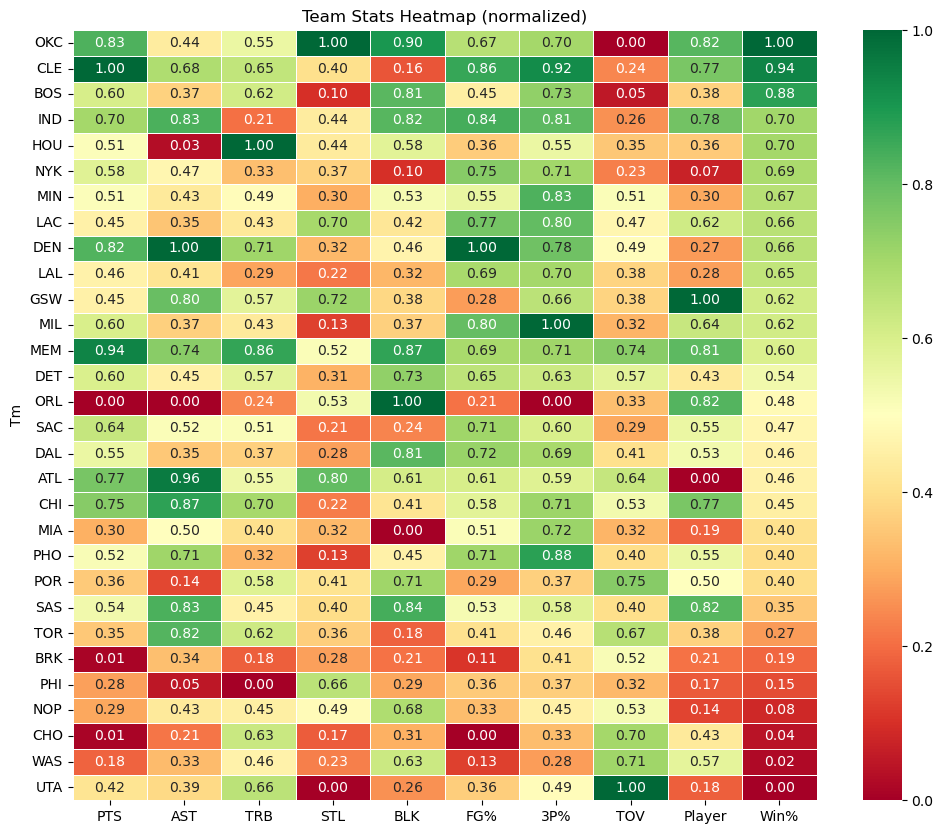

In [95]:
#Global comparaison of statistics:
stats = ["PTS", "AST", "TRB", "STL", "BLK", "FG%", "3P%", "TOV", "Player", "Win%"]

nba_heat = nba_teams.set_index("Tm")[stats].copy()
scaler = MinMaxScaler()
nba_heat[stats] = scaler.fit_transform(nba_heat[stats])
nba_heat = nba_heat.sort_values("Win%", ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(
    nba_heat,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5)
plt.title("Team Stats Heatmap (normalized)")
plt.show()

### Note about NBA 2024/2025, Team Stats Heatmap (normalized)
This graph provides a wealth of information in a highly visual way regarding the correlation between the percentage of games won and other statistics. For example, field goal percentage (FG%) and three-point percentage (3P%) are clearly positively correlated, despite some exceptions. Furthermore, we can see that overall (apart from turnovers (TOV), which should obviously be kept to a minimum, and steals (STL)), all statistics are positively correlated with the win percentage, as there is more and more green the further up the table you go.

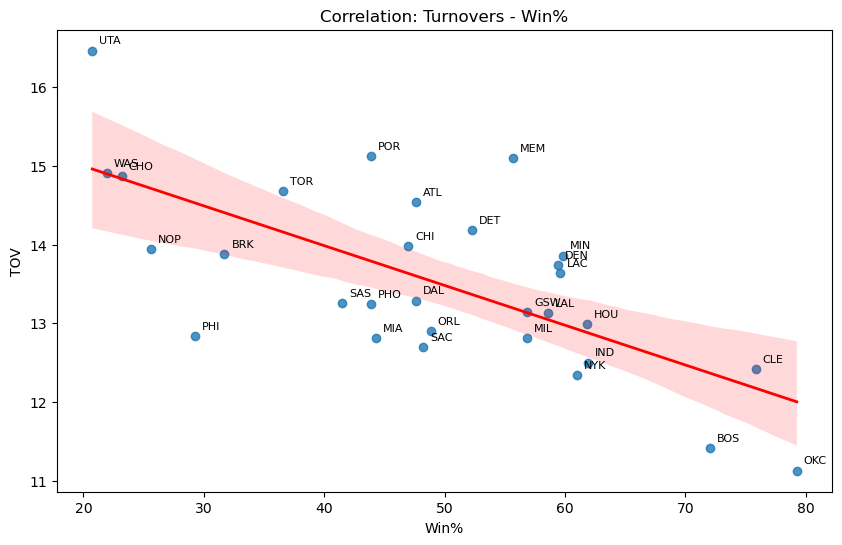

In [96]:
#analyse of correlation between TOV (Turnover = lost of ball) and %of win
plt.figure(figsize=(10, 6))

sns.regplot(
    data=nba_teams,
    x="Win%",
    y="TOV",
    line_kws={"color": "red", "linewidth": 2}) #trend
for _, row in nba_teams.iterrows(): #annotate each point
    plt.annotate(row["Tm"], (row["Win%"], row["TOV"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.title("Correlation: Turnovers - Win%")
plt.show()

### Note about "Correlation: Turnovers - Win%"
This graph clearly shows the negative correlation between a team’s turnover rate (TOV) and its win percentage. Although the teams in the middle of the table are fairly scattered, there is still a fairly strong overall trend.

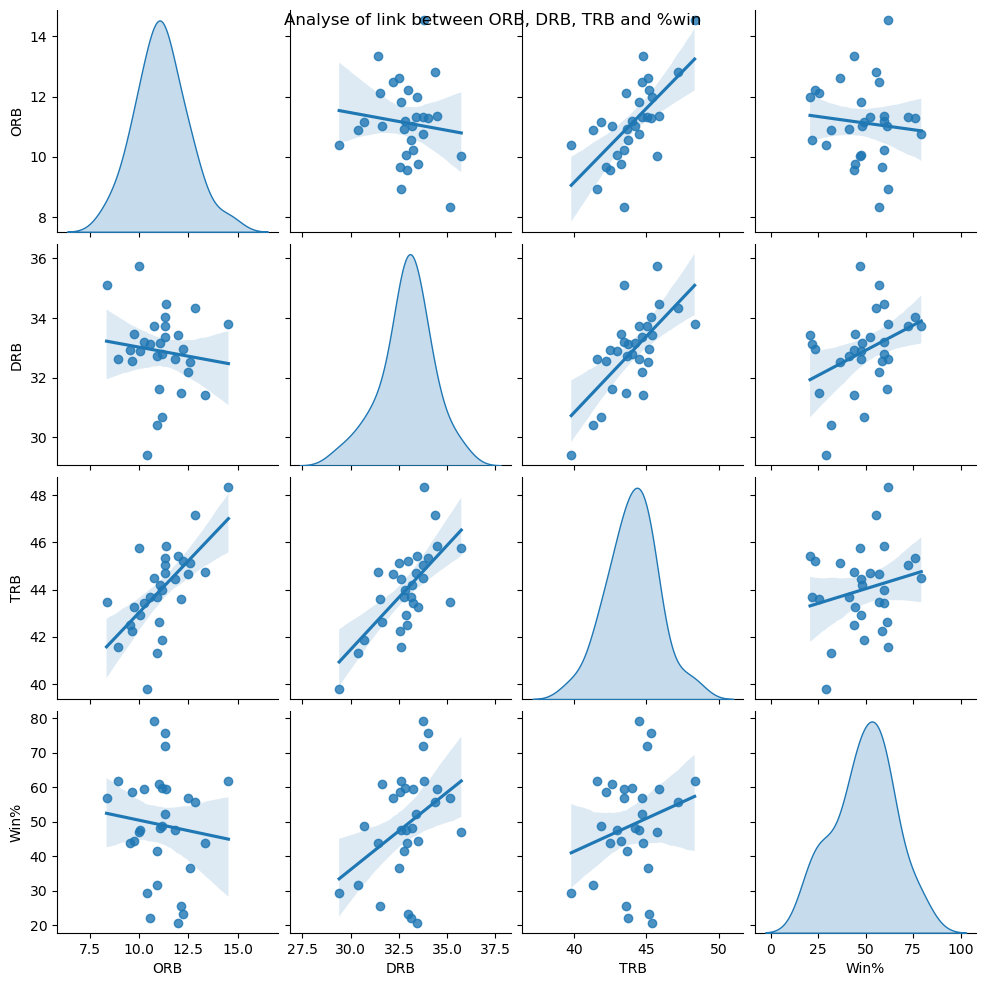

In [97]:
#analyse ORB (Offensive rebound), DRB(Defensive Rebound), TRB(Total Rebound) an win% correlation
sns.pairplot(
    nba_teams[["ORB", "DRB", "TRB", "Win%"]],
    kind="reg",         
    diag_kind="kde")
plt.suptitle ("Analyse of link between ORB, DRB, TRB and %win") 
plt.show()

### Note about Analyse of link between ORB, DRB, TRB and %win
This graph aims to identify potential correlations between the different types of rebounds (offensive ORB, defensive DRB, or total TRB). Broadly speaking, this involves retrieving the ball after a shot has been missed by one’s own team (offensive) or the opposing team (defensive). It therefore makes sense to look for correlations between ORB and DRB and TRB, since TRB is derived from the other two. As for the rest, in reality, even when the trend line appears to show a correlation, the fact that the teams’ data points are widely scattered makes this analysis unreliable.

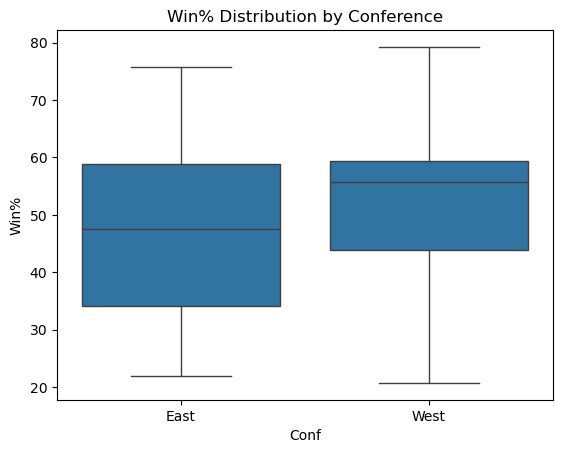

In [98]:
#Win% Distribution by Conference
sns.boxplot(data=nba_teams, x="Conf", y="Win%")
plt.title("Win% Distribution by Conference")
plt.show()

### Note about Win% Distribution by Conference
This graph shows the win percentage across the different conferences. It is often said that the Western Conference contains the best teams. Here, we can see that, in that particular year, the median win percentage for the West (approximately 55%) is higher than that for the East (approximately 48%), meaning that an ‘average’ team from the West wins more games than an ‘average’ team from the East. Furthermore, the Western Conference’s box is smaller, meaning that teams in the West are closer together in terms of ability, resulting in greater competition between them.

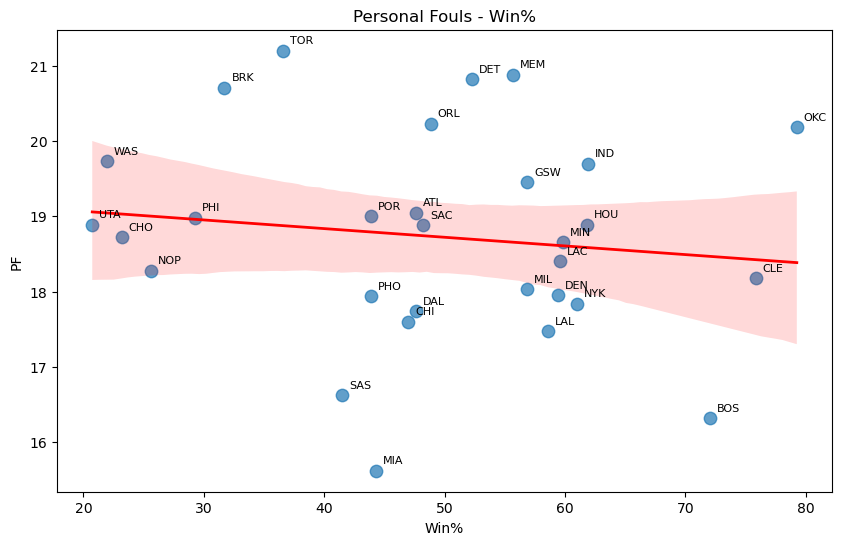

In [99]:
#Personal Fouls - Win%"
plt.figure(figsize=(10, 6))

sns.regplot(
    data=nba_teams,
    x="Win%", y="PF",
    scatter_kws={"s": 80, "alpha": 0.7},
    line_kws={"color": "red", "linewidth": 2})

for _, row in nba_teams.iterrows():
    plt.annotate(row["Tm"], (row["Win%"], row["PF"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.title("Personal Fouls - Win%")
plt.show()

### Note about Personal Fouls - Win%
This graph examines a potential correlation between the number of fouls committed and the win percentage. Here, there appears to be a very slight negative correlation, but the data points are widely scattered, so we cannot really conclude that there is any impact or logical link between the two factors.

### Conclusion
In conclusion, it appears that many factors are crucial to a winning team. However, overall, it seems that consistency across all these criteria—both defensive and offensive—is what matters most, as demonstrated by the teams at the top of the table. The overall success rate of scoring attempts seems to indicate whether a team is strong or not. Nevertheless, there is a notable difference between the win percentage and the final league position. One criterion that appears significant is turnovers (TOV), which seem to indicate a team’s ability to secure victories. It is also noted that an average team in the Western Conference has a higher potential for the number of wins, but competition is therefore fiercer. It is important to emphasise that this analysis is based on just one year, so it may only reflect exceptions.

### Export of data and result

In [100]:
nba_teams.to_csv("nba_teams_analysis.csv", index=False, encoding="utf-8")